In [1]:
import pandas as pd
df=pd.read_csv('customer_support_tickets.csv')
print(df)

      Ticket ID        Customer Name              Customer Email  \
0             1        Marisa Obrien  carrollallison@example.com   
1             2         Jessica Rios    clarkeashley@example.com   
2             3  Christopher Robbins   gonzalestracy@example.com   
3             4     Christina Dillon    bradleyolson@example.org   
4             5    Alexander Carroll     bradleymark@example.com   
...         ...                  ...                         ...   
8464       8465           David Todd          adam28@example.net   
8465       8466           Lori Davis       russell68@example.com   
8466       8467      Michelle Kelley        ashley83@example.org   
8467       8468     Steven Rodriguez         fpowell@example.org   
8468       8469      Steven Davis MD          lori20@example.net   

      Customer Age Customer Gender       Product Purchased Date of Purchase  \
0               32           Other              GoPro Hero       2021-03-22   
1               42       

In [2]:

import pandas as pd
import numpy as np
import string

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\SIMHADRI
[nltk_data]     SADWIKA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [6]:
stop_words = set(stopwords.words('english'))

def clean_txt(text):
    
    text = text.lower()
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df["clean_txt"] = df["Ticket Description"].apply(clean_text)

In [7]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_txt"])

In [8]:
y=df["Ticket Type"]

In [9]:
priority = df["Ticket Priority"]

In [10]:
df = df.dropna(subset=["Ticket Description", "Ticket Type"])

In [11]:
df["Ticket Description"] = df["Ticket Description"].astype(str)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=38
)

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.19303423848878395


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.08      0.11       327
Cancellation request       0.18      0.14      0.16       339
     Product inquiry       0.25      0.09      0.13       348
      Refund request       0.19      0.29      0.23       350
     Technical issue       0.19      0.37      0.25       330

            accuracy                           0.19      1694
           macro avg       0.20      0.19      0.18      1694
        weighted avg       0.20      0.19      0.18      1694



In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 25  57  25 105 115]
 [ 26  49  21 113 130]
 [ 20  50  31 109 138]
 [ 28  61  27 101 133]
 [ 27  60  22 100 121]]


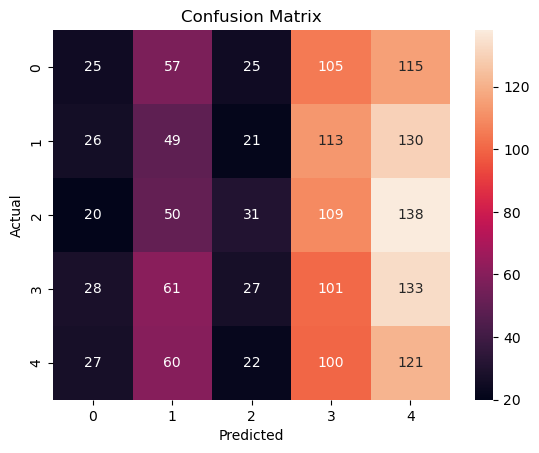

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

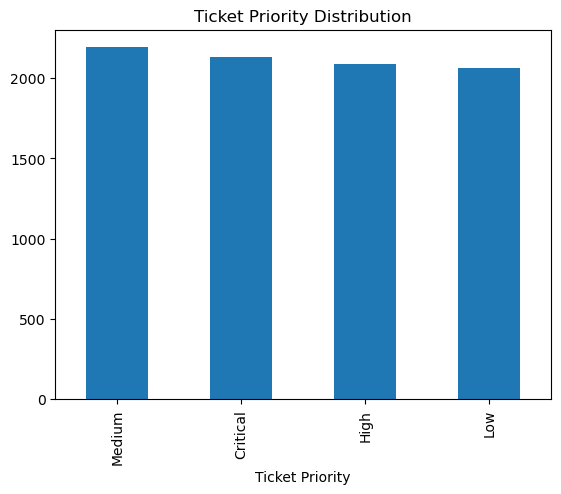

In [19]:
df["Ticket Priority"].value_counts().plot(kind="bar")

plt.title("Ticket Priority Distribution")

plt.show()

In [20]:
sample_ticket = ["My payment failed and money was deducted"]

sample_vector = vectorizer.transform(sample_ticket)

prediction = model.predict(sample_vector)

print("Predicted Category:", prediction[0])

Predicted Category: Product inquiry


In [21]:
y_priority = df["Ticket Priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=38
)

priority_model = MultinomialNB()
priority_model.fit(X_train_p, y_train_p)

priority_pred = priority_model.predict(X_test_p)

print(classification_report(y_test_p, priority_pred))

              precision    recall  f1-score   support

    Critical       0.23      0.26      0.24       419
        High       0.23      0.27      0.25       394
         Low       0.21      0.13      0.16       417
      Medium       0.27      0.29      0.28       464

    accuracy                           0.24      1694
   macro avg       0.24      0.24      0.23      1694
weighted avg       0.24      0.24      0.23      1694

